In [3]:
import os

path = r"C:\Projects\ipo-subscription-prediction\data\processed"
print("Folder exists:", os.path.exists(path))
print("Files in folder:", os.listdir(path) if os.path.exists(path) else "Folder not found!")

Folder exists: True
Files in folder: []


In [5]:
import os

path = r"C:\Projects\ipo-subscription-prediction\data\processed"
print("Files in folder:")
for f in os.listdir(path):
    print(f)

Files in folder:
ipo_enriched.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

df = pd.read_csv(r"C:\Projects\ipo-subscription-prediction\data\processed\ipo_enriched.csv")

print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:")
df.describe().round(2)

=== Dataset Overview ===
Shape: (50, 18)

Missing values:
company                  0
year                     0
issue_price              0
listing_price            0
issue_size_cr            0
qib_sub                  0
nii_sub                  0
retail_sub               0
total_sub                0
sector                   0
exchange                 0
nifty_avg                0
nifty_volatility         0
nifty_yearly_return      0
listing_gain_pct         0
issue_size_log           0
subscription_category    0
subscription_label       0
dtype: int64

Basic statistics:


,year,issue_price,listing_price,issue_size_cr,qib_sub,nii_sub,retail_sub,total_sub,nifty_avg,nifty_volatility,nifty_yearly_return,listing_gain_pct,issue_size_log,subscription_category
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,2020.62,623.88,800.46,2682.50,65.56,118.37,17.90,70.41,14537.95,1.20,19.25,37.01,7.19,2.10
std,0.73,445.52,598.20,4148.67,57.83,124.85,18.05,73.73,2304.27,0.42,5.18,54.95,1.14,0.99
min,2019.00,26.00,25.00,125.00,1.96,0.20,0.52,0.68,11141.64,0.88,2.72,-27.44,4.84,0.00
25%,2020.00,306.00,418.00,600.00,4.61,3.14,2.85,3.60,11432.80,0.99,14.77,-4.12,6.40,1.00
50%,2021.00,548.00,626.50,1172.50,52.16,68.89,11.24,46.80,16021.39,0.99,22.72,15.88,7.07,2.00
75%,2021.00,895.00,1020.75,2223.00,109.87,205.06,31.21,116.93,16021.39,1.06,22.72,74.72,7.71,3.00
max,2022.00,2150.00,2607.00,20557.00,180.35,502.49,75.04,326.49,17245.43,1.98,22.72,252.76,9.93,3.00


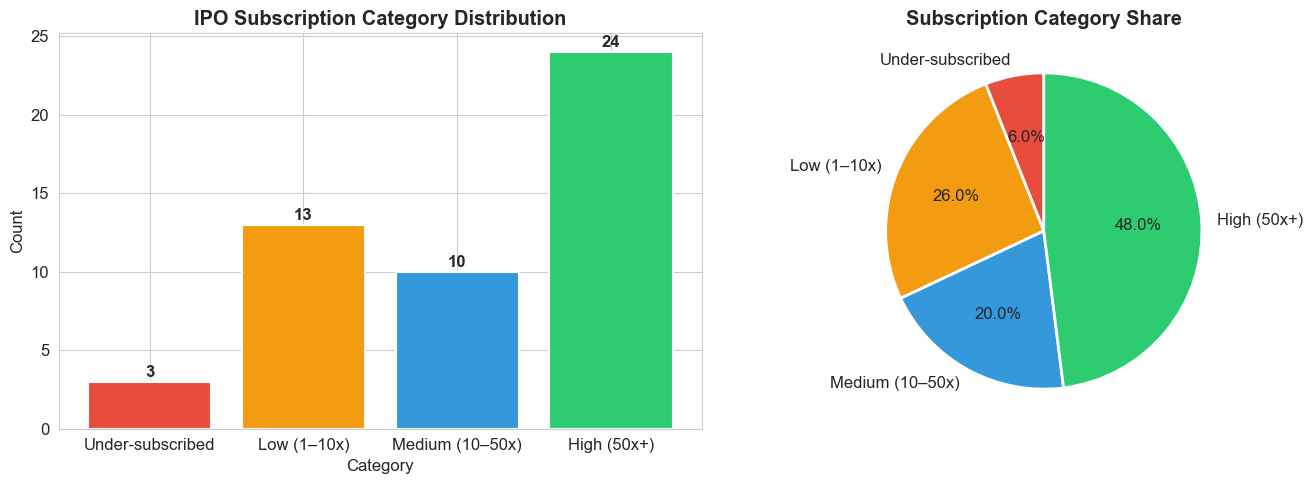

Plot saved!


In [7]:
import os
os.makedirs(r"C:\Projects\ipo-subscription-prediction\reports", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["Under-subscribed", "Low (1–10x)", "Medium (10–50x)", "High (50x+)"]
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]
counts = df["subscription_label"].value_counts().reindex(order)

axes[0].bar(order, counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("IPO Subscription Category Distribution", fontweight="bold")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=order, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Subscription Category Share", fontweight="bold")

plt.tight_layout()
plt.savefig(r"C:\Projects\ipo-subscription-prediction\reports\target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

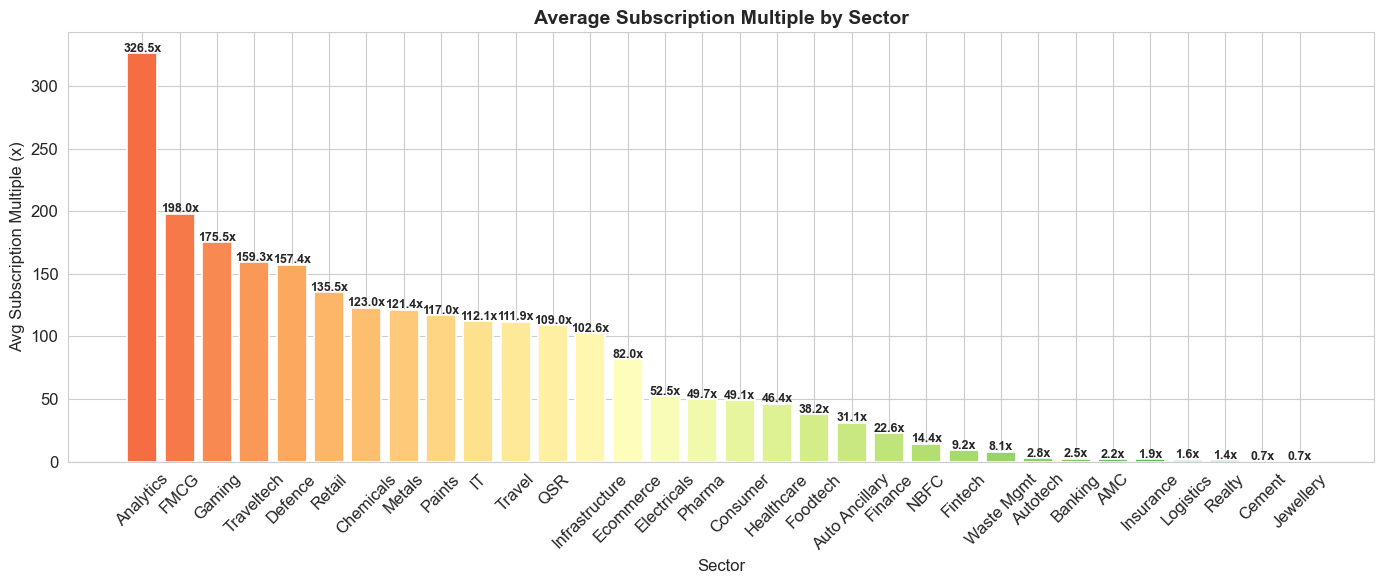

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

sector_avg = df.groupby("sector")["total_sub"].mean().sort_values(ascending=False)

bars = ax.bar(sector_avg.index, sector_avg.values,
              color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sector_avg))),
              edgecolor="white", linewidth=1.2)

ax.set_title("Average Subscription Multiple by Sector", fontweight="bold", fontsize=14)
ax.set_xlabel("Sector")
ax.set_ylabel("Avg Subscription Multiple (x)")
ax.tick_params(axis="x", rotation=45)

for bar, val in zip(bars, sector_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}x", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(r"C:\Projects\ipo-subscription-prediction\reports\sector_subscription.png", dpi=150, bbox_inches="tight")
plt.show()

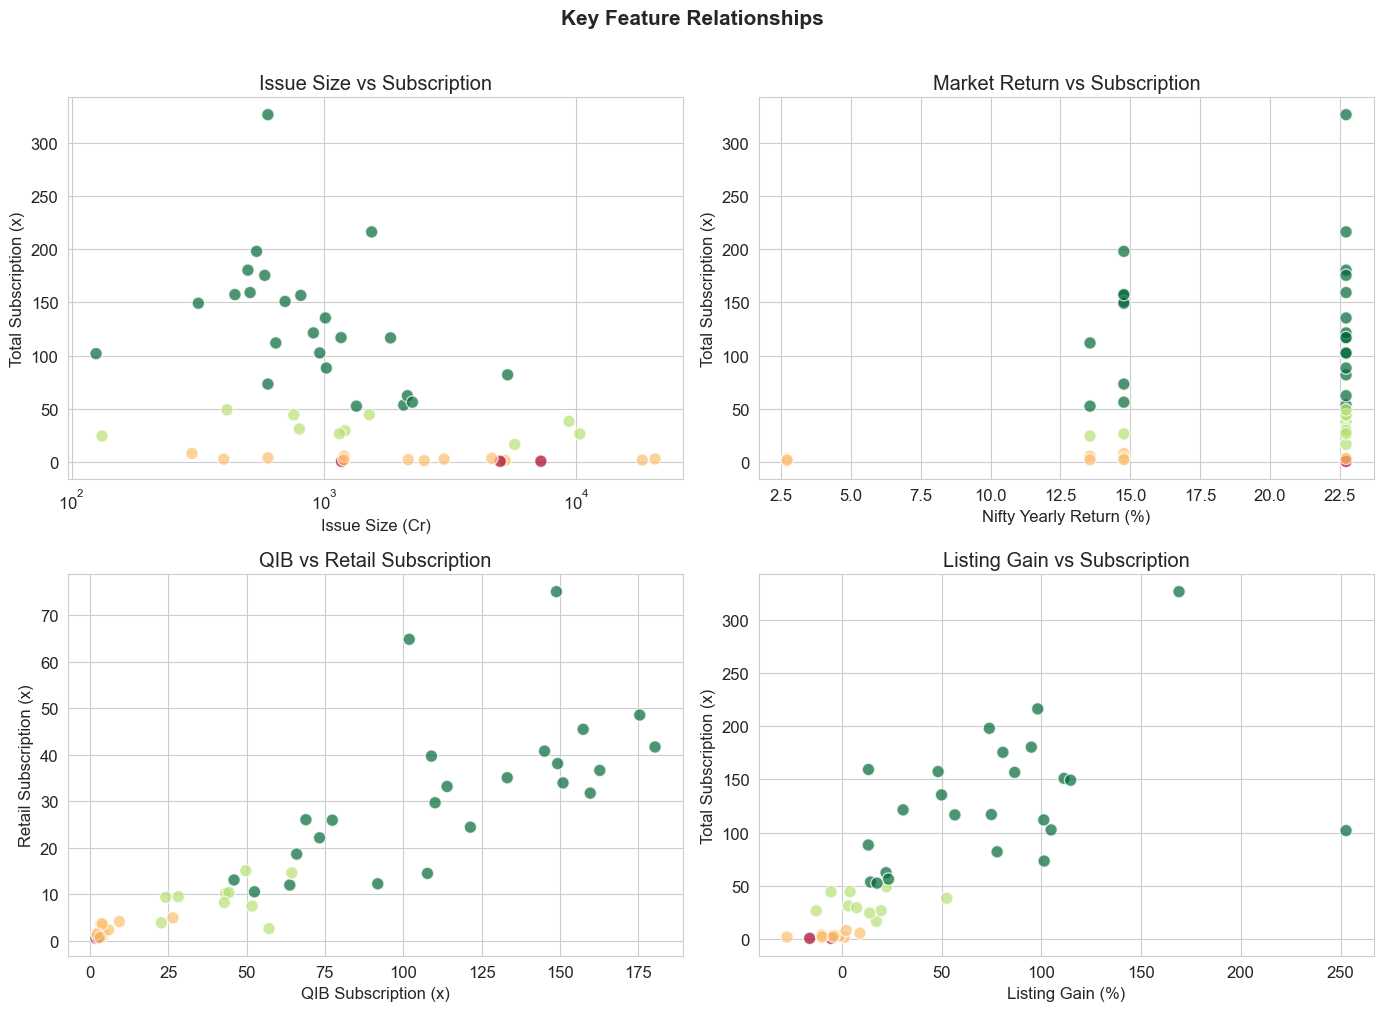

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(df["issue_size_cr"], df["total_sub"],
                  c=df["subscription_category"], cmap="RdYlGn",
                  alpha=0.7, s=80, edgecolors="white")
axes[0,0].set_xlabel("Issue Size (Cr)")
axes[0,0].set_ylabel("Total Subscription (x)")
axes[0,0].set_title("Issue Size vs Subscription")
axes[0,0].set_xscale("log")

axes[0,1].scatter(df["nifty_yearly_return"], df["total_sub"],
                  c=df["subscription_category"], cmap="RdYlGn",
                  alpha=0.7, s=80, edgecolors="white")
axes[0,1].set_xlabel("Nifty Yearly Return (%)")
axes[0,1].set_ylabel("Total Subscription (x)")
axes[0,1].set_title("Market Return vs Subscription")

axes[1,0].scatter(df["qib_sub"], df["retail_sub"],
                  c=df["subscription_category"], cmap="RdYlGn",
                  alpha=0.7, s=80, edgecolors="white")
axes[1,0].set_xlabel("QIB Subscription (x)")
axes[1,0].set_ylabel("Retail Subscription (x)")
axes[1,0].set_title("QIB vs Retail Subscription")

axes[1,1].scatter(df["listing_gain_pct"], df["total_sub"],
                  c=df["subscription_category"], cmap="RdYlGn",
                  alpha=0.7, s=80, edgecolors="white")
axes[1,1].set_xlabel("Listing Gain (%)")
axes[1,1].set_ylabel("Total Subscription (x)")
axes[1,1].set_title("Listing Gain vs Subscription")

plt.suptitle("Key Feature Relationships", fontweight="bold", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Projects\ipo-subscription-prediction\reports\feature_relationships.png", dpi=150, bbox_inches="tight")
plt.show()

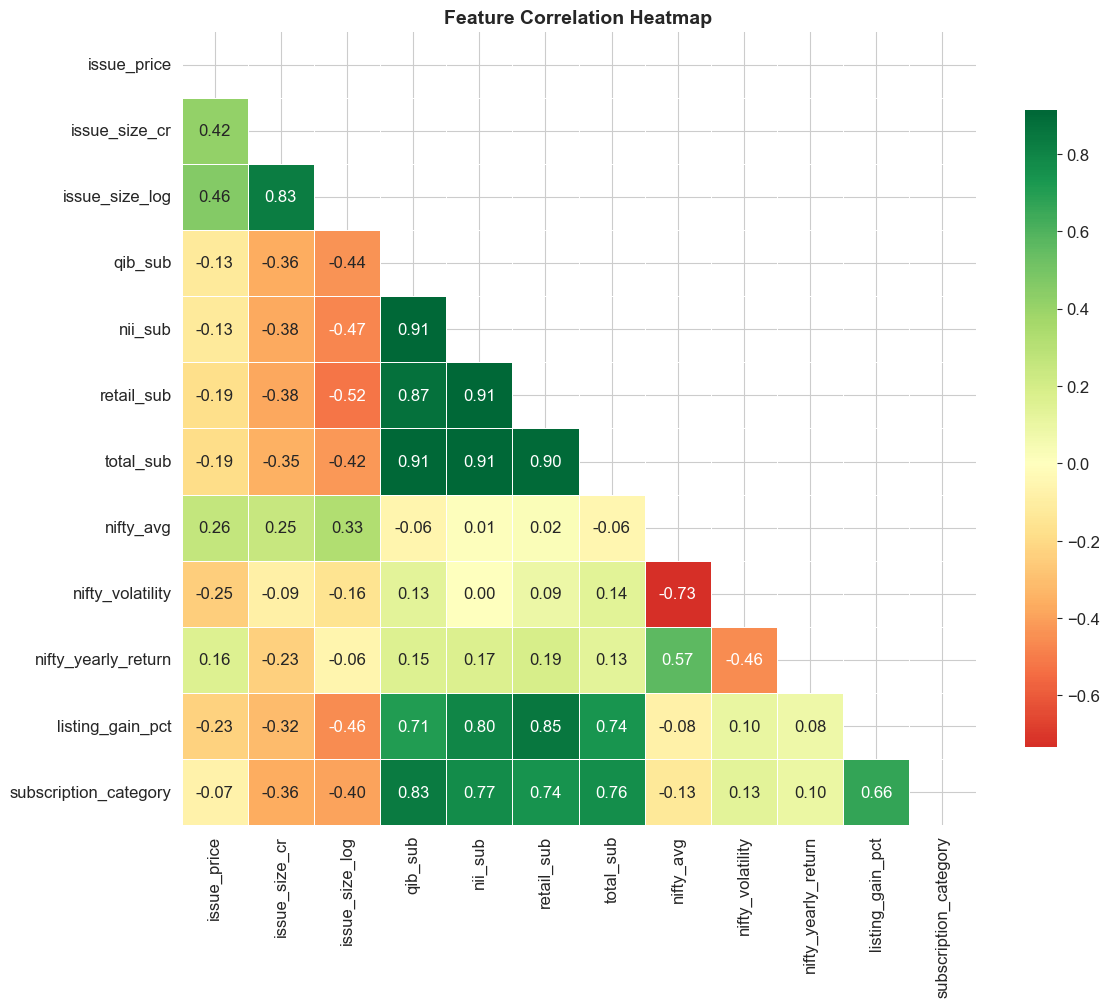


Top correlations with subscription_category:
qib_sub                0.833
nii_sub                0.766
total_sub              0.765
retail_sub             0.740
listing_gain_pct       0.664
nifty_volatility       0.132
nifty_yearly_return    0.101
issue_price           -0.075
nifty_avg             -0.130
issue_size_cr         -0.364
issue_size_log        -0.396
Name: subscription_category, dtype: float64


In [10]:
numeric_cols = ["issue_price", "issue_size_cr", "issue_size_log",
                "qib_sub", "nii_sub", "retail_sub", "total_sub",
                "nifty_avg", "nifty_volatility", "nifty_yearly_return",
                "listing_gain_pct", "subscription_category"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(r"C:\Projects\ipo-subscription-prediction\reports\correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop correlations with subscription_category:")
corr_target = corr["subscription_category"].drop("subscription_category").sort_values(ascending=False)
print(corr_target.round(3))